# 用于验证clone/weighted 策略是否有优化效果

加入临床信息

In [1]:
import pandas as pd

TNB_LONG = "/work/longyh/BY/processed/TNB/clone_weighted/TNB_long_clone_weighted.csv"
CLINICAL_XLSX = "/work/longyh/BY/raw/1-s2.0-S0092867417311224-mmc2.xlsx"

def make_response_label(df, response_col="Response"):
    df = df.copy()
    df = df[df[response_col].notna()]
    df[response_col] = df[response_col].astype(str).str.strip().str.upper()
    df = df[df[response_col] != "NE"].copy()
    response_map = {"CR": 1, "PR": 1, "SD": 0, "PD": 0}
    df["response_label"] = df[response_col].map(response_map)
    df = df.dropna(subset=["response_label"]).copy()
    df["response_label"] = df["response_label"].astype(int)
    return df

tnb = pd.read_csv(TNB_LONG)
clinical = pd.read_excel(CLINICAL_XLSX, skiprows=2)

tnb["sample"] = tnb["sample"].astype(str).str.strip()
clinical["Patient"] = clinical["Patient"].astype(str).str.strip()
clinical2 = make_response_label(clinical, "Response")

merged = pd.merge(tnb, clinical2, left_on="sample", right_on="Patient", how="inner")

print("Merged long n rows =", len(merged),
      "| n patients =", merged["sample"].nunique(),
      "| responders =", merged.drop_duplicates("sample")["response_label"].sum())

OUT = "/work/longyh/BY/processed/TNB/clone_weighted/TNB_long_clone_weighted_with_clinical.csv"
merged.to_csv(OUT, index=False)
print("Saved:", OUT)


Merged long n rows = 4448 | n patients = 22 | responders = 6
Saved: /work/longyh/BY/processed/TNB/clone_weighted/TNB_long_clone_weighted_with_clinical.csv


# 分析作图

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_CSV = "/work/longyh/BY/processed/TNB/clone_weighted/TNB_long_clone_weighted_with_clinical.csv"
OUTDIR = "/work/longyh/BY/plots"
File_OUTDIR="/work/longyh/BY/processed/TNB/clone_weighted"

os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(IN_CSV)

# 基本字段确认
print(df.columns)

# responder label
df["response_label"] = df["response_label"].astype(int)

# 方便画图：文本标签
df["Response_group"] = df["response_label"].map({1:"Responder",0:"Non-responder"})


Index(['sample', 'unit', 'metric_family', 'binder_metric', 'strategy',
       'clonal_cutoff', 'value', 'n_total_unique', 'Patient', 'Cohort',
       'Response', 'Dead/Alive\n(Dead = True)', 'Time to Death\n(weeks)',
       'Subtype', 'Mutational\n Subtype', 'M Stage', 'Mutation Load',
       'Neo-antigen Load', 'Neo-peptide Load', 'Cytolytic Score',
       'response_label'],
      dtype='object')


In [6]:
summary = (
    df
    .groupby([
        "unit",
        "metric_family",
        "binder_metric",
        "strategy",
        "clonal_cutoff"
    ])
    .agg(
        n_patients=("sample","nunique"),
        mean_value=("value","mean"),
        median_value=("value","median"),
        std_value=("value","std")
    )
    .reset_index()
)

OUT_SUM = f"{File_OUTDIR}/TNB_summary_long_clone_weighted.csv"
summary.to_csv(OUT_SUM, index=False)

print("Saved summary:", OUT_SUM)
print(summary.head())


Saved summary: /work/longyh/BY/processed/TNB/clone_weighted/TNB_summary_long_clone_weighted.csv
          unit metric_family binder_metric strategy clonal_cutoff  n_patients  \
0  hla_peptide         count          ic50       S1           all          22   
1  hla_peptide         count          ic50       S1      vaf>=0.2          22   
2  hla_peptide         count          ic50       S1     vaf>=0.25          22   
3  hla_peptide         count          ic50       S1      vaf>=0.3          22   
4  hla_peptide         count          ic50       S1     vaf>=0.35          22   

   mean_value  median_value   std_value  
0  168.590909         127.5  144.797941  
1  113.227273          41.5  142.201377  
2   95.636364          22.5  127.108332  
3   71.409091          16.0  103.581419  
4   49.090909          12.5   80.461117  


In [19]:
import pandas as pd

p = "/work/longyh/BY/processed/TNB/clone_weighted/TNB_summary_long_clone_weighted.csv"
df = pd.read_csv(p)

print(df.columns.tolist())
print(df.head(3))
print("binder_metric unique:", df["binder_metric"].unique())


['unit', 'metric_family', 'binder_metric', 'strategy', 'clonal_cutoff', 'n_patients', 'mean_value', 'median_value', 'std_value']
          unit metric_family binder_metric strategy clonal_cutoff  n_patients  \
0  hla_peptide         count          ic50       S1           all          22   
1  hla_peptide         count          ic50       S1      vaf>=0.2          22   
2  hla_peptide         count          ic50       S1     vaf>=0.25          22   

   mean_value  median_value   std_value  
0  168.590909         127.5  144.797941  
1  113.227273          41.5  142.201377  
2   95.636364          22.5  127.108332  
binder_metric unique: ['ic50' 'rank']


In [20]:
# 假设 binder_metric 的 unique 里有 'IC50'
sub = df[df["binder_metric"] == "ic50"]

print(sub[["mean_value","median_value","std_value"]].describe())
print("max(mean) =", sub["mean_value"].max())
print("max(median) =", sub["median_value"].max())
print("max(std) =", sub["std_value"].max())


       mean_value  median_value   std_value
count  120.000000    120.000000  120.000000
mean    15.007576      7.308333   17.899185
std     32.399887     19.772039   36.243572
min      0.000000      0.000000    0.000000
25%      0.000000      0.000000    0.000000
50%      0.090909      0.000000    0.250541
75%      9.784091      5.750000   12.231317
max    168.590909    127.500000  144.797941
max(mean) = 168.5909090909091
max(median) = 127.5
max(std) = 144.7979410176254


In [21]:
p2 = "/work/longyh/BY/processed/TNB/clone_weighted/TNB_long_clone_weighted_with_clinical.csv"
raw = pd.read_csv(p2)

print(raw.columns.tolist())
print("binder_metric unique:", raw["binder_metric"].unique())

# 用 raw 里真实的 IC50 取值替换下面的 "IC50"
ic50_tag = "IC50"

print("IC50 count sum =",
      raw.query("binder_metric==@ic50_tag and metric_family=='count'")["value"].sum())

print("IC50 weighted sum =",
      raw.query("binder_metric==@ic50_tag and metric_family=='weighted'")["value"].sum())

print("IC50 count max =",
      raw.query("binder_metric==@ic50_tag and metric_family=='count'")["value"].max())

print("IC50 weighted max =",
      raw.query("binder_metric==@ic50_tag and metric_family=='weighted'")["value"].max())


['sample', 'unit', 'metric_family', 'binder_metric', 'strategy', 'clonal_cutoff', 'value', 'n_total_unique', 'Patient', 'Cohort', 'Response', 'Dead/Alive\n(Dead = True)', 'Time to Death\n(weeks)', 'Subtype', 'Mutational\n Subtype', 'M Stage', 'Mutation Load', 'Neo-antigen Load', 'Neo-peptide Load', 'Cytolytic Score', 'response_label']
binder_metric unique: ['ic50' 'rank']
IC50 count sum = 0.0
IC50 weighted sum = 0.0
IC50 count max = nan
IC50 weighted max = nan


In [22]:
import pandas as pd

p2 = "/work/longyh/BY/processed/TNB/clone_weighted/TNB_long_clone_weighted_with_clinical.csv"
raw = pd.read_csv(p2)

print("Columns:", raw.columns.tolist())
print("binder_metric unique:", raw["binder_metric"].unique())
print("metric_family unique:", raw["metric_family"].unique())

# 自动识别 IC50 标签（兼容 'ic50'/'IC50'）
cands = [x for x in raw["binder_metric"].unique() if str(x).lower() in ["ic50", "ic50score", "ic50_score"]]
ic50_tag = cands[0] if cands else "IC50"
print("Using ic50_tag =", ic50_tag)

sub_count = raw[(raw["binder_metric"] == ic50_tag) & (raw["metric_family"] == "count")]
sub_w = raw[(raw["binder_metric"] == ic50_tag) & (raw["metric_family"] == "weighted")]

print("IC50 count:  nrows =", len(sub_count), " sum =", sub_count["value"].sum(), " max =", sub_count["value"].max())
print("IC50 weight: nrows =", len(sub_w),     " sum =", sub_w["value"].sum(),     " max =", sub_w["value"].max())
print("IC50 count nonzero rows =", (sub_count["value"] > 0).sum())
print("IC50 weight nonzero rows =", (sub_w["value"] > 0).sum())


Columns: ['sample', 'unit', 'metric_family', 'binder_metric', 'strategy', 'clonal_cutoff', 'value', 'n_total_unique', 'Patient', 'Cohort', 'Response', 'Dead/Alive\n(Dead = True)', 'Time to Death\n(weeks)', 'Subtype', 'Mutational\n Subtype', 'M Stage', 'Mutation Load', 'Neo-antigen Load', 'Neo-peptide Load', 'Cytolytic Score', 'response_label']
binder_metric unique: ['ic50' 'rank']
metric_family unique: ['count' 'weighted']
Using ic50_tag = ic50
IC50 count:  nrows = 1320  sum = 39620.0  max = 521.0
IC50 weight: nrows = 873  sum = 0.0  max = 0.0
IC50 count nonzero rows = 873
IC50 weight nonzero rows = 0


ORR 分布图

In [7]:
plot_df = df.query(
    "unit=='mutation' & metric_family=='count' & binder_metric=='rank' & clonal_cutoff=='vaf>=0.25'"
).copy()


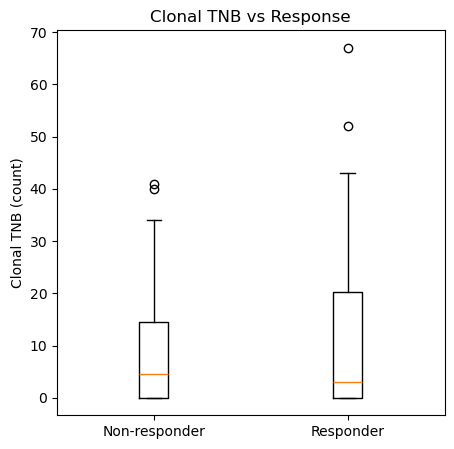

In [9]:
plt.figure(figsize=(5,5))

groups = [
    plot_df.loc[plot_df["response_label"]==0,"value"],
    plot_df.loc[plot_df["response_label"]==1,"value"]
]

plt.boxplot(groups)
plt.xticks([1,2],["Non-responder","Responder"])
plt.ylabel("Clonal TNB (count)")
plt.title("Clonal TNB vs Response")

plt.savefig(f"{OUTDIR}/box_clonalTNB_rank_mutation_vaf025.png", dpi=300)
plt.show()
plt.close()


Logistic 回归 + ROC

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

X = plot_df[["value"]].values
y = plot_df["response_label"].values

model = LogisticRegression()
model.fit(X,y)

prob = model.predict_proba(X)[:,1]
auc = roc_auc_score(y,prob)

print("AUC =", auc)


/home/longyh/miniforge3/envs/py310/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


AUC = 0.5208333333333333


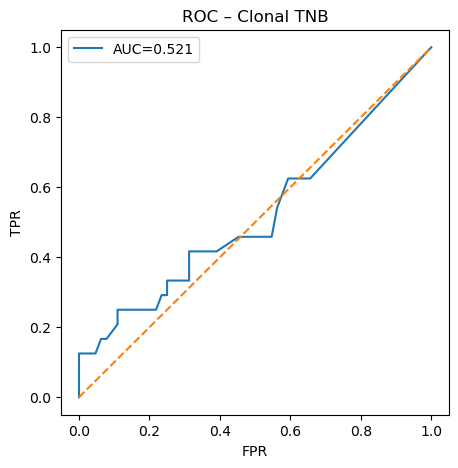

In [11]:
fpr,tpr,_ = roc_curve(y,prob)

plt.figure(figsize=(5,5))
plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("ROC – Clonal TNB")

plt.savefig(f"{OUTDIR}/ROC_clonalTNB_rank_mutation_vaf025.png", dpi=300)
plt.show()
plt.close()


阈值扫描热图

In [12]:
scan_df = df.query(
    "unit=='mutation' & metric_family=='count' & binder_metric=='rank'"
).copy()

# 计算每个阈值组合的 AUC
rows = []

for strat in scan_df["strategy"].unique():
    for cutoff in scan_df["clonal_cutoff"].unique():

        sub = scan_df.query(
            "strategy==@strat & clonal_cutoff==@cutoff"
        )

        if sub["sample"].nunique() < 10:
            continue

        X = sub[["value"]].values
        y = sub["response_label"].values

        if len(np.unique(y))<2:
            continue

        auc = roc_auc_score(y,X)

        rows.append([strat,cutoff,auc])

heat = pd.DataFrame(rows,columns=["strategy","cutoff","auc"])


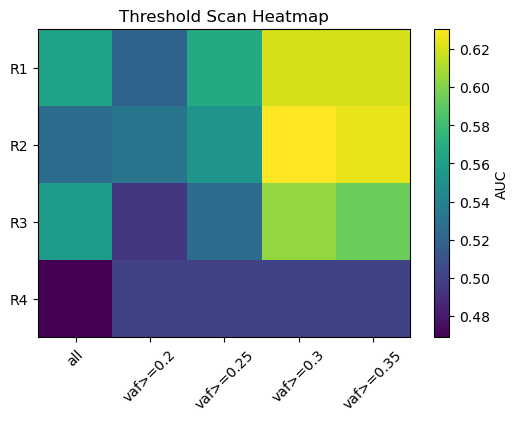

In [14]:
pivot = heat.pivot(index="strategy",columns="cutoff",values="auc")

plt.figure(figsize=(6,4))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="AUC")

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.title("Threshold Scan Heatmap")

plt.savefig(f"{OUTDIR}/heatmap_rank_clonal_scan.png", dpi=300)
plt.show()
plt.close()


Weighted vs Count 对比图（B2 是否带来改进）

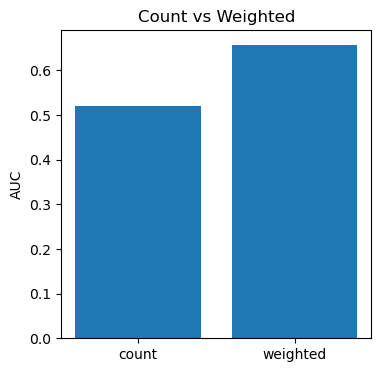

In [15]:
compare = df.query(
    "unit=='mutation' & binder_metric=='rank' & clonal_cutoff=='vaf>=0.25'"
)

rows = []

for fam in ["count","weighted"]:
    sub = compare.query("metric_family==@fam")

    auc = roc_auc_score(sub["response_label"], sub["value"])
    rows.append([fam,auc])

cmp = pd.DataFrame(rows,columns=["metric","AUC"])

plt.figure(figsize=(4,4))
plt.bar(cmp["metric"],cmp["AUC"])
plt.ylabel("AUC")
plt.title("Count vs Weighted")

plt.savefig(f"{OUTDIR}/AUC_count_vs_weighted.png", dpi=300)
plt.show()
plt.close()


# 新的分析作图

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

merged = pd.read_csv("/work/longyh/BY/processed/TNB/clone_weighted/TNB_long_clone_weighted_with_clinical.csv")


/home/longyh/miniforge3/envs/py310/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
def make_key(df):
    return (df["unit"].astype(str) + "|" +
            df["binder_metric"].astype(str) + "|" +
            df["strategy"].astype(str) + "|" +
            df["metric_family"].astype(str) + "|" +
            df["clonal_cutoff"].astype(str))

merged["key"] = make_key(merged)
merged = merged.drop_duplicates(subset=["sample","key"])

# 只做 mutation 主分析
df = merged[merged["unit"].eq("mutation")].copy()


In [4]:

# 你需要在这里选定“预先定义”的两个 key（示例）
baseline_key = "mutation|rank|R1|count|all"
b2_key       = "mutation|rank|R1|count|vaf>=0.3"

def get_patient_xy(d, key):
    g = d[d["key"].eq(key)][["sample","value","response_label"]].drop_duplicates("sample")
    g = g.dropna(subset=["value","response_label"])
    return g["response_label"].astype(int).to_numpy(), g["value"].astype(float).to_numpy(), g

y0, x0, g0 = get_patient_xy(df, baseline_key)
y1, x1, g1 = get_patient_xy(df, b2_key)

# 对齐患者集合（非常重要：paired 比较必须同一批患者）
common = sorted(set(g0["sample"]) & set(g1["sample"]))
g0c = g0[g0["sample"].isin(common)].set_index("sample").loc[common]
g1c = g1[g1["sample"].isin(common)].set_index("sample").loc[common]
y = g0c["response_label"].to_numpy()
x_base = g0c["value"].to_numpy()
x_b2 = g1c["value"].to_numpy()

print("n patients =", len(common), "responders =", int(y.sum()))


n patients = 22 responders = 6


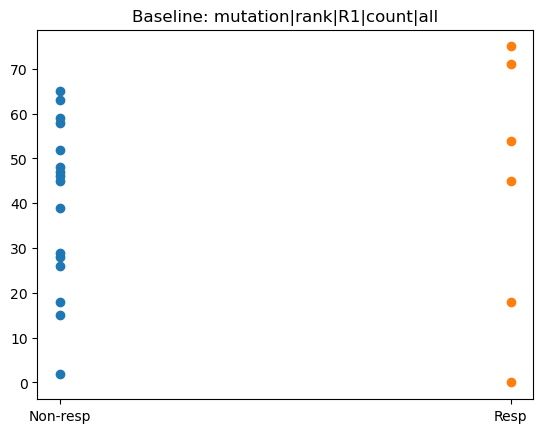

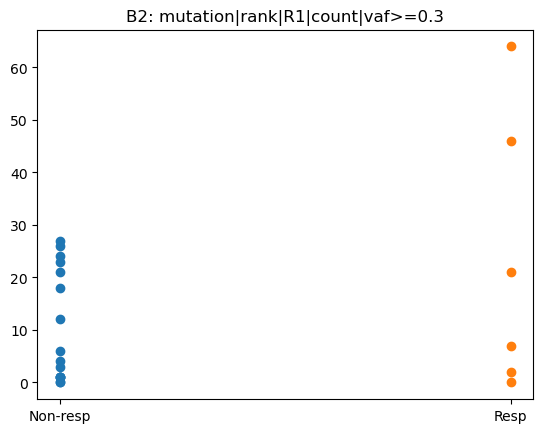

In [5]:
# 1) ORR 分布图（box + scatter）
plt.figure()
for lab, xs in [(0, x_base[y==0]), (1, x_base[y==1])]:
    plt.scatter([lab]*len(xs), xs)
plt.xticks([0,1], ["Non-resp","Resp"])
plt.title(f"Baseline: {baseline_key}")
plt.show()

plt.figure()
for lab, xs in [(0, x_b2[y==0]), (1, x_b2[y==1])]:
    plt.scatter([lab]*len(xs), xs)
plt.xticks([0,1], ["Non-resp","Resp"])
plt.title(f"B2: {b2_key}")
plt.show()


AUC baseline = 0.5625 | AUC B2 = 0.6197916666666667


<Figure size 640x480 with 0 Axes>

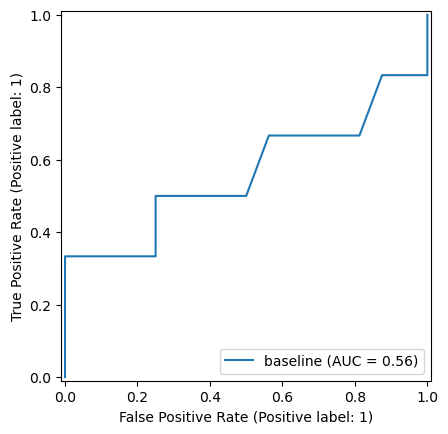

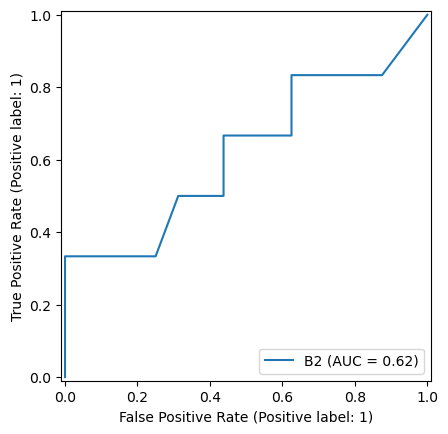

In [6]:
# 2) logistic + ROC（单变量，标准化）
def fit_auc(y, x):
    X = StandardScaler().fit_transform(x.reshape(-1,1))
    lr = LogisticRegression(solver="liblinear")
    lr.fit(X, y)
    p = lr.predict_proba(X)[:,1]
    auc = roc_auc_score(y, p)
    return auc, lr.coef_[0,0], lr.intercept_[0], p

auc0, b0, a0, p0 = fit_auc(y, x_base)
auc1, b1, a1, p1 = fit_auc(y, x_b2)

print("AUC baseline =", auc0, "| AUC B2 =", auc1)

plt.figure()
RocCurveDisplay.from_predictions(y, p0, name="baseline")
RocCurveDisplay.from_predictions(y, p1, name="B2")
plt.show()


In [7]:

# 3) paired bootstrap ΔAUC
def paired_boot_delta_auc(y, x0, x1, n_boot=2000, seed=1):
    rng = np.random.default_rng(seed)
    n = len(y)
    deltas = []
    kept = 0
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb = y[idx]
        if len(np.unique(yb)) < 2:
            continue
        auc0 = roc_auc_score(yb, x0[idx])
        auc1 = roc_auc_score(yb, x1[idx])
        deltas.append(auc1 - auc0)
        kept += 1
    deltas = np.array(deltas)
    lo, hi = np.quantile(deltas, [0.025, 0.975])
    p_pos = (deltas > 0).mean()
    return lo, hi, p_pos, kept

lo, hi, p_pos, kept = paired_boot_delta_auc(y, x_base, x_b2, n_boot=2000, seed=1)
print("ΔAUC(B2-baseline) 95%CI =", (lo, hi), "| P(Δ>0)=", p_pos, "| kept=", kept)


ΔAUC(B2-baseline) 95%CI = (-0.20000000000000007, 0.30602328431372544) | P(Δ>0)= 0.6875312969454181 | kept= 1997
